<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Task1_DataCleaning_Assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving bank-loan.csv to bank-loan (1).csv


   age  ed  employ  address  income  debtinc   creddebt   othdebt  default
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0
(850, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: 

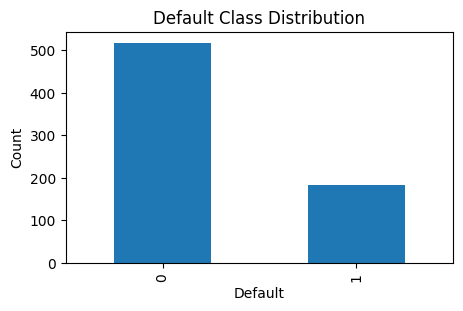

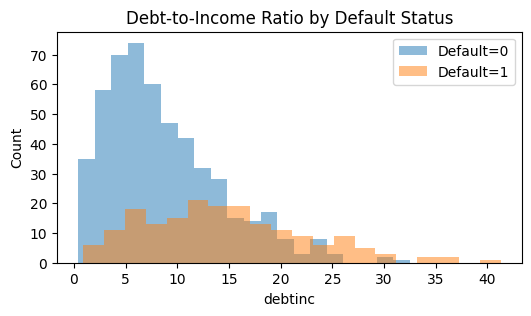

In [4]:
# Task 1: Data Loading & Cleaning
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('bank-loan.csv')

# Quick inspection
print(df.head())
print(df.shape)
print(df.info())

# Check missing values
print(df.isnull().sum())

# Keep rows with known target values only
df = df.dropna(subset=['default'])

# Summary statistics
print(df.describe())

# Simple visualizations
plt.figure(figsize=(5, 3))
df['default'].astype(int).value_counts().sort_index().plot(kind='bar')
plt.title('Default Class Distribution')
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 3))
for label, subset in df.groupby('default'):
    plt.hist(subset['debtinc'], bins=20, alpha=0.5, label=f'Default={int(label)}')
plt.title('Debt-to-Income Ratio by Default Status')
plt.xlabel('debtinc')
plt.ylabel('Count')
plt.legend()
plt.show()

# Handle missing values
df = df.fillna(df.median(numeric_only=True))

# Encode categorical if needed
df = pd.get_dummies(df)

